In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import sys
from copy import deepcopy,copy
from datetime import datetime
import pickle
import sys
import matplotlib.pyplot as plt
import warnings
from ipywidgets import IntProgress
from scipy.signal import savgol_filter
#warnings.filterwarnings("ignore")
#warnings.filterwarnings("ignore", category=RuntimeWarning)
stderr_fileno = sys.stderr
sys.stderr = open(os.devnull, 'w')

src = os.path.dirname('/export/home/oriolca/Integral_BMS_Governing_Equations/I-BMS/')
sys.path.append(src)
from mcmc_ode import *
from parallel_ode import *

path = os.path.join(src, "Prior/")
sys.path.append(path)
from fit_prior import read_prior_par

priors = {
    "v2_p3": f"Prior/final_prior_param_sq.named_equations.nv2.np3.2016-09-09 18:49:42.927679.dat",
    "v2_p4": f"Prior/final_prior_param_sq.named_equations.nv2.np4.2016-09-09 18:49:43.056910.dat",
    "v2_p8": f"Prior/final_prior_param_sq.named_equations.nv2.np8.2016-09-09 18:49:42.800618.dat",
    "v3_p8": f"Prior/final_prior_param_sq.named_equations.nv3.np6.maxs50.2021-12-14 09:51:44.438445.dat",
}

def rossler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    dxdt = -y-z
    dydt = x+a*y
    dzdt = b + z*(x-c)
    return [dxdt, dydt, dzdt]

# Parameters
t_span = (0, 100)
t_eval = np.linspace(*t_span, 10000)  # 10k points
x0 = [1.0, 1.0, 1.0]  # initial conditions

# Integrate the Lorenz system
sol = solve_ivp(rossler, t_span, x0, t_eval=t_eval, method='RK45', rtol=1e-9, atol=1e-9)

eps = 10 ** -(40 / 20)
# Convert to a pandas DataFrame for convenience
data = pd.DataFrame({'t': sol.t,
                     'x': sol.y[0] + eps * np.random.normal(scale=np.std(sol.y[0]), size=sol.y[0].shape),
                     'y': sol.y[1]+ eps * np.random.normal(scale=np.std(sol.y[1]), size=sol.y[1].shape),
                     'z': sol.y[2]+ eps * np.random.normal(scale=np.std(sol.y[2]), size=sol.y[2].shape)})

print(data)

x = data[['x','y','z']]
t = pd.Series(data[['t']].t)

dt = t.to_numpy()[1] - t.to_numpy()[0]
window_length = 41    # must be odd and <= len(t)
polyorder = 3         # generally 2..5

x_hat = savgol_filter(x['x'], window_length, polyorder, delta=dt, mode='interp')
y_hat = savgol_filter(x['y'], window_length, polyorder, delta=dt, mode='interp')
z_hat = savgol_filter(x['z'], window_length, polyorder, delta=dt, mode='interp')

#x['x'] = x_hat
#x['y'] = y_hat

x_dot = savgol_filter(x['x'], window_length, polyorder, deriv=1, delta=dt, mode='interp')
y_dot = savgol_filter(x['y'], window_length, polyorder, deriv=1, delta=dt, mode='interp')
z_dot = savgol_filter(x['z'], window_length, polyorder, deriv=1, delta=dt, mode='interp')

dx = [pd.DataFrame(data = {'x': x_hat, 'y': y_hat, 'z': z_hat}),pd.DataFrame(data = {'x': x_dot, 'y': y_dot, 'z': z_dot})]

print(x)

print(t)

print(dx)

               t         x         y         z
0       0.000000  1.005110  1.051704  1.007180
1       0.010001  0.967661  1.061771  0.956050
2       0.020002  0.994445  1.047724  0.916592
3       0.030003  0.977603  0.950372  0.878864
4       0.040004  0.824907  1.075170  0.827914
...          ...       ...       ...       ...
9995   99.959996  9.611550 -3.886567  0.670157
9996   99.969997  9.527921 -3.880472  0.688873
9997   99.979998  9.555201 -3.611539  0.723841
9998   99.989999  9.671127 -3.617420  0.783956
9999  100.000000  9.593565 -3.597264  0.794707

[10000 rows x 4 columns]
             x         y         z
0     1.005110  1.051704  1.007180
1     0.967661  1.061771  0.956050
2     0.994445  1.047724  0.916592
3     0.977603  0.950372  0.878864
4     0.824907  1.075170  0.827914
...        ...       ...       ...
9995  9.611550 -3.886567  0.670157
9996  9.527921 -3.880472  0.688873
9997  9.555201 -3.611539  0.723841
9998  9.671127 -3.617420  0.783956
9999  9.593565 -3.597264 

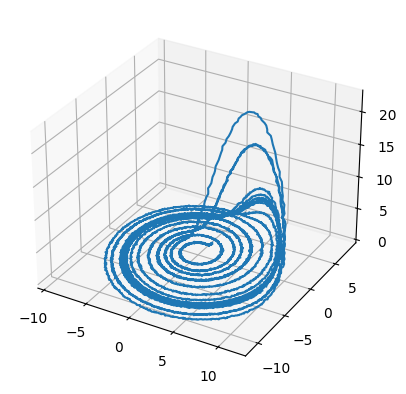

In [2]:
ax = plt.figure().add_subplot(projection='3d')
ax.plot(x['x'], x['y'], x['z'], label='parametric curve')

plt.show()

In [ ]:
%%time
XLABS = ['x','y','z']
n_params = 8

path = os.path.join(src, priors[f"v{len(XLABS)}_p{str(n_params)}"])
prior_par = read_prior_par(path)

Ts=[1] + [1.04**k for k in range(1, 20)]

del prior_par['Nopi_abs']
del prior_par['Nopi2_abs']
del prior_par['Nopi_tan']
del prior_par['Nopi2_tan']
del prior_par['Nopi_sinh']
del prior_par['Nopi2_sinh']
del prior_par['Nopi_cosh']
del prior_par['Nopi2_cosh']
del prior_par['Nopi_tanh']
del prior_par['Nopi2_tanh']


OPS = {
    "sin": 1,
    "cos": 1,
    "exp": 1,
    "pow2": 1,
    "pow3": 1,
    "-": 1,
    "+": 2,
    "*": 2,
    "/": 2,
    "**": 2,
}
import time

start = time.time()
pms_x = Parallel(
    ops=OPS,
    Ts=Ts,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
)

pms_y = Parallel(
    ops=OPS,
    Ts = Ts,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
)

pms_z = Parallel(
    ops=OPS,
    Ts = Ts,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
)



couplings=[pms_x,pms_y,pms_z]
pms_x.set_couplings(couplings)

nsteps = 1000

f = IntProgress(min=0, max=nsteps, description='Running:') # instantiate the bar
display(f)
mdl = np.inf
dl=[]

last_seen_by_can, last_seen_by_str = {}, {}
for coup in pms_x.trees.values():
    last_seen_by_can[tuple(f.canonical() for f in coup.couplings)] = 0
    last_seen_by_str[tuple(str(f) for f in coup.couplings)] = 0
NCLEAN = 200

for k in range(nsteps):
    pms_x.mcmc_step()
    pms_y.mcmc_step()
    pms_z.mcmc_step()
    pms_x.tree_swap()
    if pms_x.t1.E.val < mdl:
        model_x = deepcopy(pms_x.t1)
        model_y = deepcopy(pms_y.t1)
        model_z = deepcopy(pms_z.t1)
        mdl = copy(pms_x.t1.E.val)
    dl.append(copy(pms_x.t1.E.val))
    f.value+=1
    for coup in pms_x.trees.values():
        last_seen_by_can[tuple(f.canonical() for f in coup.couplings)] = k
        last_seen_by_str[tuple(str(f) for f in coup.couplings)] = k
    if (k % NCLEAN) == 0:
        to_remove = []
        for represent in pms_x.t1.representative:
            try:
                if last_seen_by_can[represent] < (k - NCLEAN):
                    to_remove.append(represent)
            except KeyError:  # This tree was tested but not visited anyway!
                to_remove.append(represent)
        for t in to_remove:
            del pms_x.t1.representative[t]
            if t in last_seen_by_can:
                del last_seen_by_can[t]
        to_remove = []
        for string in pms_x.t1.fit_par:
            try:
                if last_seen_by_str[string] < (k - NCLEAN):
                    to_remove.append(string)
            except KeyError:  # This tree was tested but not visited anyway!
                to_remove.append(string)
        for t in to_remove:
            del pms_x.t1.fit_par[t]
            del pms_x.t1.fit_x0[t]
            del pms_x.t1.fit_sse[t]
            if t in last_seen_by_str:
                del last_seen_by_str[t]
    if k%5==0:
        print(f'{k}--{pms_x.t1}({pms_x.t1.E.val})|{pms_y.t1}({pms_y.t1.E.val})|{pms_z.t1}({pms_z.t1.E.val})',end='\r')
print('PT (T=1) final model',pms_x.t1.E,pms_x.t1)
print('PT (T=1) final model',pms_y.t1.E,pms_y.t1)
print('PT (T=1) final model',pms_z.t1.E,pms_z.t1)


print(model_x)
print(model_x.E)
print(model_x.par_values)
print(model_x.x0_values)

plt.plot(dl)
plt.show()

<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNumber 30330.06752839568> <SharedNumber 30330.06752839568>
<SharedNum

IntProgress(value=0, description='Running:', max=1000)

In [ ]:
model_x.integrator=Integrator('rk45')
model_y.integrator=Integrator('rk45')
model_z.integrator=Integrator('rk45')
del model_x.fit_par[(str(model_x),str(model_y),str(model_z))]
model_x.get_sse(fit=True)
integral = model_x.integrate(t)

plt.plot(t,integral['d0']['x'])
plt.plot(t,x['x'],'--')
plt.show()
plt.plot(t,integral['d0']['y'])
plt.plot(t,x['y'],'--')
plt.show()
plt.plot(t,integral['d0']['z'])
plt.plot(t,x['z'],'--')
plt.show()

In [ ]:
ax = plt.figure(figsize=(10,10)).add_subplot(projection='3d')
ax.plot(integral['d0']['x'], integral['d0']['y'], integral['d0']['z'], label='parametric curve')
ax.plot(x['x'], x['y'], x['z'],'--', label='parametric curve')

plt.show()

In [ ]:
dx_pred = model_x.predict(x)

plt.plot(x['x'],dx_pred['x'])
plt.plot(x['x'],dx['x'],'--')
plt.show()
plt.plot(x['y'],dx_pred['y'])
plt.plot(x['y'],dx['y'],'--')
plt.show()
plt.plot(x['x'],dx_pred['z'])
plt.plot(x['x'],dx['z'],'--')
plt.show()